# Dimensionality Reduction

**PCA Feature Extraction of FRED and Index Variables**

Author: Pete King

We reduce the dimensionality of the FRED and index variables using Principal Component Analysis (PCA) for a few reasons:
 1. To reduce "noise" in the data and emphasize the singal we want our models to pay attention to
 2. To reduce multicollinearity in the data
 3. To extract a smaller set of features to use as input variables to our models

Rather than lump all variables together in a single run, we separate variables into major groups, using financial domain knowledge as our guide:

 - Volatility indicies: VIX, VXN, MOVE
 - Macroeconomic data and other infrequently reported variables
 - Other indicies: Commodities, equities, and all ETF historical volatilities


In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import pickle
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

import data_prep as dp
import viz

DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_ALL_DATA.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_ALL_DATA.csv'
TEST_DATA_FILE = DATA_FOLDER + 'test_ALL_DATA.csv'

## I. Data Preparation

### Import financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
test_df = pd.read_csv(
    TEST_DATA_FILE,
    index_col='date',
    parse_dates=True
)

### Separate features into desired groups

In [3]:
X_cols, _ = dp.get_X_y_cols(train_df)
# Volatility indicies
vol = ['^MOVE', '^VIX', '^VXN']
# Macroeconomic and other variables
macro = [
    'one_month_yield_diff', 'three_month_yield_diff', 'six_month_yield_diff',
    'one_year_yield_diff', 'two_year_yield_diff', 'five_year_yield_diff',
    'ten_year_yield_diff', 'thirty_year_yield_diff',
    '^TNX_diff',
    'nominal_GDP_chg', 'real_GDP_chg', 'debt_to_GDP_chg', 'debt_interest_chg',
    'consumer_price_index_chg', 'core_PCI_chg',
    'personal_consumption_expenditure_chg', 'core_PCE_chg',
    'producer_price_index_chg', 'unemployment_rate_chg',
    'teenager_unemployment_rate_chg', 'adult_unemployment_rate_chg',
    'male_unemployment_rate_chg', 'female_unemployment_rate_chg',
    'average_duration_of_unemployment_chg',
    'initial_jobless_claims_chg',
    'continued_jobless_claims_chg'
]
# Historical volatility of other indicies
p = re.compile(r'.+_h-vol$')
indicies = [var for var in X_cols if p.match(var) is not None]

### Scale data

In [4]:
scaler = MinMaxScaler()
# Take care to fit scaler only to training data
X_train = pd.DataFrame(
    scaler.fit_transform(train_df[X_cols]),
    index=train_df.index,
    columns=X_cols
)
X_val = pd.DataFrame(
    scaler.transform(val_df[X_cols]),
    index=val_df.index,
    columns=X_cols
)
X_test = pd.DataFrame(
    scaler.transform(test_df[X_cols]),
    index=test_df.index,
    columns=X_cols
)

## II. Apply PCA for feature extraction

*Note: We only fit PCA to training data to avoid data leakage*

In [5]:
# Volatility indicies
pca_vol = PCA()
X_train_vol = pca_vol.fit_transform(X_train[vol])
X_val_vol = pca_vol.transform(X_val[vol])
X_test_vol = pca_vol.transform(X_test[vol])
# Macroeconomic data
pca_macro = PCA()
X_train_macro = pca_macro.fit_transform(X_train[macro])
X_val_macro = pca_macro.transform(X_val[macro])
X_test_macro = pca_macro.transform(X_test[macro])
# Other indicies
pca_indicies = PCA()
X_train_indicies = pca_indicies.fit_transform(X_train[indicies])
X_val_indicies = pca_indicies.transform(X_val[indicies])
X_test_indicies = pca_indicies.transform(X_test[indicies])

### Scree plots: Explained variance ratio

#### Volatility Indicies

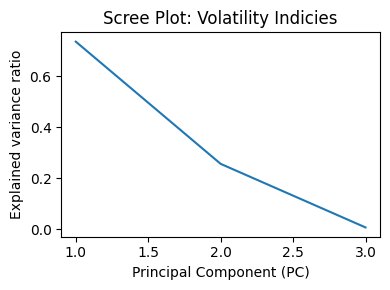

In [6]:
data = np.asarray(
    [(i + 1, ratio) for i, ratio in enumerate(pca_vol.explained_variance_ratio_)]
)
viz.elbow_plot(
    data=data,
    title='Scree Plot: Volatility Indicies',
    xlabel='Explained variance ratio',
    ylabel='Principal Component (PC)'
)

In [7]:
pca_vol.explained_variance_ratio_

array([0.73618296, 0.25663306, 0.00718397])

The first component alone explains 74% of the variation in the volatility indexes.

#### Macroeconomic Data

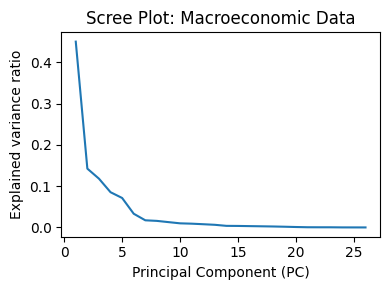

In [8]:
data = np.asarray(
    [(i + 1, ratio) for i, ratio in enumerate(pca_macro.explained_variance_ratio_)]
)
viz.elbow_plot(
    data=data,
    title='Scree Plot: Macroeconomic Data',
    xlabel='Explained variance ratio',
    ylabel='Principal Component (PC)'
)

In [9]:
pca_macro.explained_variance_ratio_

array([4.50138666e-01, 1.42457572e-01, 1.18159552e-01, 8.53432155e-02,
       7.13914525e-02, 3.31991508e-02, 1.72837064e-02, 1.58808860e-02,
       1.28876370e-02, 9.95437159e-03, 9.12873276e-03, 7.79778397e-03,
       6.38767050e-03, 3.84314275e-03, 3.63949959e-03, 3.20480035e-03,
       2.78141478e-03, 2.33303736e-03, 1.73564639e-03, 1.03347794e-03,
       4.76932876e-04, 3.85719196e-04, 3.69380446e-04, 1.03064158e-04,
       5.78475798e-05, 2.56403433e-05])

The first three components explain 71% of the variation in macroeconomic data.

#### Historical Volatility (Other indicies)

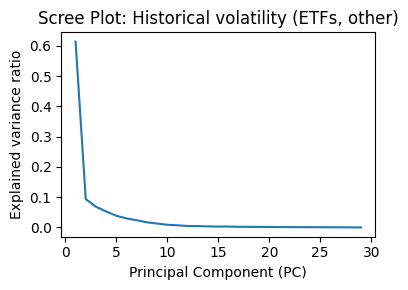

In [10]:
data = np.asarray(
    [(i + 1, ratio) for i, ratio in enumerate(pca_indicies.explained_variance_ratio_)]
)
viz.elbow_plot(
    data=data,
    title='Scree Plot: Historical volatility (ETFs, other)',
    xlabel='Explained variance ratio',
    ylabel='Principal Component (PC)'
)

In [11]:
pca_indicies.explained_variance_ratio_

array([6.14083080e-01, 9.35122958e-02, 6.84095983e-02, 5.28273955e-02,
       3.86201565e-02, 2.98558007e-02, 2.39171090e-02, 1.69554778e-02,
       1.28922104e-02, 8.87010249e-03, 7.10776399e-03, 4.90324763e-03,
       4.40002715e-03, 3.53351278e-03, 2.90176153e-03, 2.86992863e-03,
       2.22975070e-03, 2.05314369e-03, 1.78837910e-03, 1.69839225e-03,
       1.33078117e-03, 1.15038296e-03, 9.89634413e-04, 8.93779495e-04,
       7.64558732e-04, 6.00415082e-04, 5.25294443e-04, 2.37979442e-04,
       7.80405340e-05])

The first two components explain 71% of the variance in all indicies' historical volatility.

## III. Save Principal Features

In selecting which principal features to retain, want to strike a balance between capturing variation in the data and increasing the complexity of our models.  As our investigations with the full feature set have shown, not all the variation in these features is relevant to to our target variables.  We choose to retain roughly 70 percent of the variance for each group of features:

 - 1 component for the volatility indicies
 - 3 components for the macroeconomic variables
 - 2 components for the historical volatility indicies

### Principal Features: Training Data

In [12]:
# Create PCA DataFrame for extracted training features
train_data = np.asarray(
    [
        X_train_vol[:, 0],
        X_train_macro[:, 0],
        X_train_macro[:, 1],
        X_train_macro[:, 2],
        X_train_indicies[:, 0],
        X_train_indicies[:, 1]
    ]
)
train_data = train_data.reshape(-1, len(train_data))

In [13]:
pca_train_df = pd.DataFrame(
    train_data,
    columns=[
        'PCA_vol-1',
        'PCA_macro-1', 'PCA_macro-2', 'PCA_macro-3',
        'PCA_indicies-1', 'PCA_indicies-2'
    ],
    index=train_df.index
)
pca_train_df

,PCA_vol-1,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_indicies-1,PCA_indicies-2
date,,,,,,
2015-10-22,-0.060385,-0.049302,-0.045180,-0.042780,-0.051164,-0.030192
2015-10-23,-0.027020,-0.035612,-0.031673,0.003920,-0.004416,-0.028761
2015-10-26,-0.019623,-0.042593,-0.040932,-0.026452,-0.008330,-0.036960
2015-10-27,-0.000326,-0.024071,-0.030029,-0.043408,-0.038998,-0.035716
2015-10-28,-0.048401,-0.050450,-0.037413,-0.043599,-0.024643,0.013070
...,...,...,...,...,...,...
2022-11-25,0.185472,0.220728,0.214587,0.241583,0.273974,0.279569
2022-11-28,0.304949,0.332873,0.340876,0.364613,0.323324,0.296187
2022-11-29,0.304061,0.285759,0.417160,0.498473,0.493811,0.484565


### Principal Features: Validation Data

In [14]:
# Create PCA DataFrame for extracted validation features
val_data = np.asarray(
    [
        X_val_vol[:, 0],
        X_val_macro[:, 0],
        X_val_macro[:, 1],
        X_val_macro[:, 2],
        X_val_indicies[:, 0],
        X_val_indicies[:, 1]
    ]
)
val_data = val_data.reshape(-1, len(val_data))

In [15]:
pca_val_df = pd.DataFrame(
    val_data,
    columns=[
        'PCA_vol-1',
        'PCA_macro-1', 'PCA_macro-2', 'PCA_macro-3',
        'PCA_indicies-1', 'PCA_indicies-2'
    ],
    index=val_df.index
)
pca_val_df

,PCA_vol-1,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_indicies-1,PCA_indicies-2
date,,,,,,
2023-01-03,0.453110,0.416835,0.381414,0.326702,0.354621,0.360311
2023-01-04,0.337204,0.291585,0.291259,0.358576,0.305696,0.317675
2023-01-05,0.311223,0.310984,0.294959,0.261770,0.240383,0.213406
2023-01-06,0.250842,0.217873,0.185065,0.198466,0.206405,0.258067
2023-01-09,0.235417,0.230884,0.254676,0.296916,0.303690,0.282478
...,...,...,...,...,...,...
2024-08-26,0.293126,0.292533,0.316186,0.243624,0.288977,0.267867
2024-08-27,0.278305,0.310627,0.348494,0.650686,0.598126,0.639431
2024-08-28,0.619731,0.622704,0.499503,0.551470,0.563498,0.528452


### Principal Features: Test Data

In [16]:
# Create PCA DataFrame for extracted validation features
test_data = np.asarray(
    [
        X_test_vol[:, 0],
        X_test_macro[:, 0],
        X_test_macro[:, 1],
        X_test_macro[:, 2],
        X_test_indicies[:, 0],
        X_test_indicies[:, 1]
    ]
)
test_data = test_data.reshape(-1, len(test_data))

In [17]:
pca_test_df = pd.DataFrame(
    test_data,
    columns=[
        'PCA_vol-1',
        'PCA_macro-1', 'PCA_macro-2', 'PCA_macro-3',
        'PCA_indicies-1', 'PCA_indicies-2'
    ],
    index=test_df.index
)
pca_test_df

,PCA_vol-1,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_indicies-1,PCA_indicies-2
date,,,,,,
2024-10-01,0.222081,0.205526,0.214056,0.195804,0.385820,0.372165
2024-10-02,0.359116,0.322814,0.330873,0.355470,0.396070,0.350367
2024-10-03,0.344975,0.339205,0.379862,0.381409,0.390816,0.377105
2024-10-04,0.394196,0.405892,0.406700,0.408935,0.462560,0.432324
2024-10-07,0.457452,0.403707,0.277027,0.180592,0.149017,0.180296
...,...,...,...,...,...,...
2026-02-19,0.018826,0.017603,0.014903,0.021015,0.019941,0.030768
2026-02-20,0.004134,0.082286,0.059808,0.054382,0.028675,0.050174
2026-02-23,-0.025469,-0.156074,-0.182923,-0.164129,-0.126991,-0.152893


### Save Principal Features as CSV files

In [18]:
pca_train_df.to_csv(
    DATA_FOLDER + 'train_pca_data.csv',
    index_label='date'
)
pca_val_df.to_csv(
    DATA_FOLDER + 'val_pca_data.csv',
    index_label='date'
)
pca_test_df.to_csv(
    DATA_FOLDER + 'test_pca_data.csv',
    index_label='date'
)